# Figure 2

In [1]:

import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy import stats
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault
from src.utils.tools import seed_everything

add_feature_bin = False
eid = "E116"
fold = 0


targets = ['bs_label','bf_label']
npy_dir = "extra/datasets/processed/v1"

meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

binsizes = [500]

#
# Setup end.
#
seed=123
meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # load and shuffle.



EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


# Figure 2A

     eid  fold       auc    target
0   E116     0  0.916103  bs_label
1   E116     0  0.899636  bf_label
2   E116     1  0.923317  bs_label
3   E116     1  0.911211  bf_label
4   E116     2  0.935525  bs_label
5   E116     2  0.895294  bf_label
6   E116     3  0.920027  bs_label
7   E116     3  0.900732  bf_label
8   E118     0  0.776445  bs_label
9   E118     0  0.872285  bf_label
10  E118     1  0.809220  bs_label
11  E118     1  0.888016  bf_label
12  E118     2  0.810345  bs_label
13  E118     2  0.887382  bf_label
14  E118     3  0.818125  bs_label
15  E118     3  0.872875  bf_label
16  E003     0  0.818580  bs_label
17  E003     0  0.934369  bf_label
18  E003     1  0.805720  bs_label
19  E003     1  0.940339  bf_label
20  E003     2  0.823372  bs_label
21  E003     2  0.936079  bf_label
22  E003     3  0.812042  bs_label
23  E003     3  0.949671  bf_label
     eid  fold       auc    target
0   E116     0  0.786737  bs_label
1   E116     0  0.975279  bf_label
2   E116     1  0.78

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12265/160610688.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_12265/160610688.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)


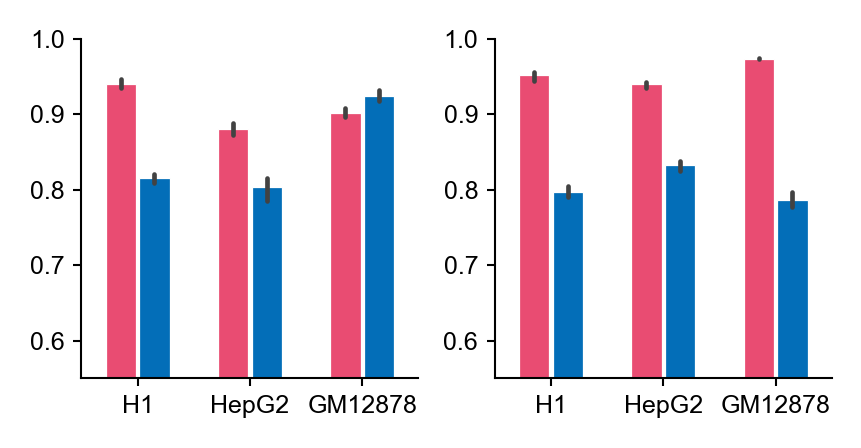

In [3]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')

palette = ['#E94C72','#036EB8']

data = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
# 关键修改：横坐标缩小 100 倍
data['auc'] = data['auc'] / 100
print(data)
hue_order = ['bf_label','bs_label']
sns.barplot(data=data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[0],order=order,hue='target',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)


# Show the plot
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylim(ymin=0.55, ymax=1.0)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title('AUC (4-fold CV)\nlabels from txburst')

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]

data = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
# 关键修改：横坐标缩小 100 倍
data['auc'] = data['auc'] / 100
print(data)
hue_order = ['bf_label','bs_label']
sns.barplot(data=data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[1],order=order,hue='target',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)

    
# Show the plot
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].set_ylim(ymin=0.55, ymax=1.0)
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title("AUC (4-fold CV)\nlabels from DeepTX")

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]


fig.legend().remove()
# plt.savefig('extra/figures/v7/Figure2A.eps', format='eps', bbox_inches='tight')

plt.show()

In [22]:
data = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
# 关键修改：横坐标缩小 100 倍
data['auc'] = data['auc'] / 100
data.groupby(['eid','target']).mean()

fold       auc
eid  target                  
E003 bf_label   1.5  0.940115
     bs_label   1.5  0.814928
E116 bf_label   1.5  0.901718
     bs_label   1.5  0.923743
E118 bf_label   1.5  0.880139
     bs_label   1.5  0.803534

# Figure 2B

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/2651249096.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]}" for eid in order])
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/2651249096.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels([f"" for eid in order])


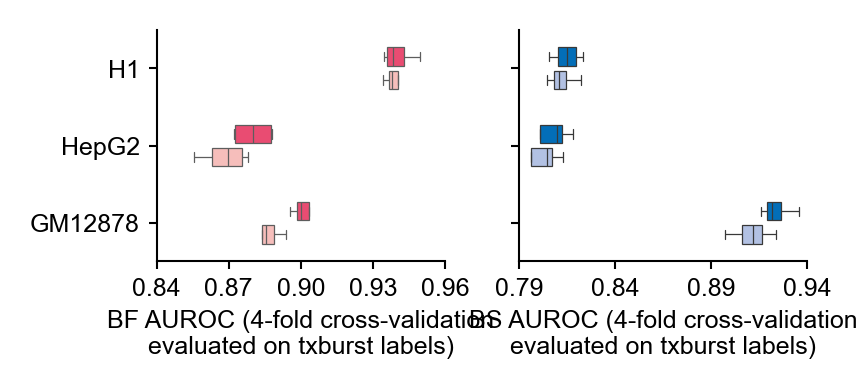

In [6]:
deeptx_to_txburst_indicators = pd.read_csv('extra/results/bs_bf_deeptx_to_txburst_indicators.csv')
deeptx_to_txburst_indicators['train'] = 'deeptx'
deeptx_to_txburst_indicators['valid'] = 'txburst'
txburst_indicators = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
txburst_indicators['train'] = 'txburst'
txburst_indicators['valid'] = 'txburst'
data = pd.concat([deeptx_to_txburst_indicators, txburst_indicators], ignore_index=True)
# 关键修改：横坐标缩小 100 倍
data['auc'] = data['auc'] / 100

hue_order = ['txburst','deeptx']
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7/2.54, 3/2.54))
palette = ['#E94C72',"#F6BEBB"]
sns.boxplot(data=data[data['target']=='bf_label'],y='eid',x='auc',hue='train',fliersize=0, linewidth=0.3,order=order,hue_order=hue_order,
            gap=0.2,width=0.6,palette=palette,ax=ax[0],saturation=1)

ax[0].set_ylabel("",fontsize=6)
ax[0].tick_params(axis='y', labelsize=6,width=0.5)
ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]}" for eid in order])
ax[0].set_xlabel("BF AUROC (4-fold cross-validation\nevaluated on txburst labels)")
ax[0].set_xlim(0.84)
xticks = [i/100 for i in range(84,97,3)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[0].set_xticks(xticks, labels=xticklabels)
ax[0].legend().remove()

palette = ["#036EB8","#B2C1E3"]
sns.boxplot(data=data[data['target']=='bs_label'],y='eid',x='auc',hue='train',fliersize=0, linewidth=0.3,order=order,hue_order=hue_order,
            gap=0.2,width=0.6,palette=palette,ax=ax[1],saturation=1)

ax[1].set_ylabel("",fontsize=6)
ax[1].tick_params(axis='y', labelsize=6,width=0.5)
ax[1].set_yticklabels([f"" for eid in order])
ax[1].set_xlabel("BS AUROC (4-fold cross-validation\nevaluated on txburst labels)")
ax[1].set_xlim(0.79,0.94)
xticks = [i/100 for i in range(79,95,5)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[1].set_xticks(xticks, labels=xticklabels)
ax[1].legend().remove()
plt.savefig('extra/figures/v7/Figure2B.eps', format='eps', bbox_inches='tight')
plt.show()

# Figure 2C

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/4270324152.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/4270324152.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)


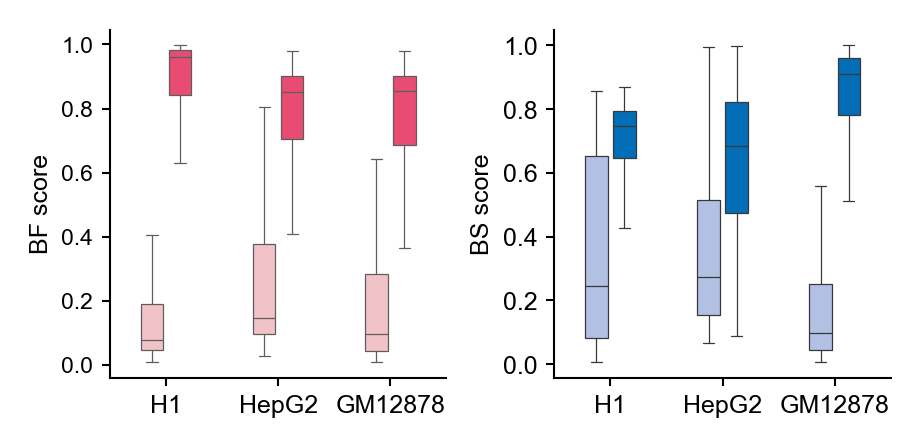

In [7]:
import scipy.stats as stats
order = pd.Index(["E003","E118","E116"],name='marks')
data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')

palette1 = ["#F1C3C8","#E94C72"]
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7.5/2.54, 3.5/2.54))

# sns.stripplot(data=data2,x='bf_label_label',y='bf_label_score',s=0.1,ax=ax[0],palette=palette)
sns.boxplot(data=data,x='eid',y='bf_label_score',hue='bf_label_label',
            fliersize=0,ax=ax[0],
            palette=palette1,
            linewidth=0.3,
            order=order,
            width=0.5,
            gap=0.2,
            saturation=1,
        )
# ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[0].set_ylabel('BF score', fontsize=6)
ax[0].set_xlabel('',fontsize=6)
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)


palette2 = ["#B2C1E3","#036EB8"]
# sns.stripplot(data=data2,x='bf_label_label',y='bf_label_score',s=0.1,ax=ax[0],palette=palette)
sns.boxplot(data=data,x='eid',y='bs_label_score',hue='bs_label_label',
            fliersize=0,
            ax=ax[1],
            palette=palette2,
            linewidth=0.3,
            order=order,
            width=0.5,
            gap=0.2,
            saturation=1,
        )
# ax[0].set_title('Frequency',fontsize=6,fontweight='regular')
ax[1].set_ylabel('BS score', fontsize=6)
ax[1].set_xlabel('',fontsize=6)
ax[0].tick_params(axis='y', labelsize=5.5,width=0.5)


ax[0].legend().remove()
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],)

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette1[1], label='High burst freq. genes'),
    mpatches.Patch(color=palette1[0], label='Low burst freq. genes'),
    mpatches.Patch(color=palette2[1], label='High burst size genes'),
    mpatches.Patch(color=palette2[0], label='Low burst size genes'),
]
# fig.legend(handles=legend_patches, title="", loc="upper left", bbox_to_anchor=(0.98, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')
plt.savefig('extra/figures/v7/Figure2C.eps', format='eps', bbox_inches='tight')

plt.show()

# Figure 2D

/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


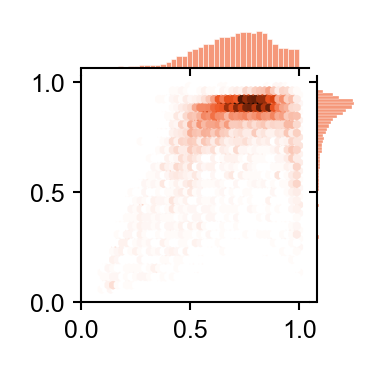

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
palette = ["#F2764D","#FDDF91"]
# 设定 EID
eid = 'E118'

# 读取数据
data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')
data = data[data['eid'] == eid]
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

# 设定随机种子
seed = 123
np.random.seed(seed)

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 加载并打乱数据

# 数据合并
data = pd.merge(data, meta[['gene_id', 'mean', 'mean_label', 'sc_exp_label', 'cv_label']], how='inner', on='gene_id')


g = sns.jointplot(
    data=data[data['sc_exp_label'] == 1],
    x='bs_label_score', 
    y='bf_label_score', 
    color=palette[0],
    kind='hex',
    height=3/2.54,     # 主图高度（单位：英寸）
)
g.ax_joint.set_ylabel('', fontsize=6)
g.ax_joint.set_xlabel('', fontsize=6)
g.ax_joint.set_title('', fontsize=6, fontweight='regular',y=1.1)
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])

# fig.legend(handles=legend_patches, title=None, loc="upper left", bbox_to_anchor=(0.95, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

# **保存图像**
plt.savefig(f'extra/figures/v7/Figure2D_{eid}_1.eps', format='eps', bbox_inches='tight')

# 显示图像
plt.show()

/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


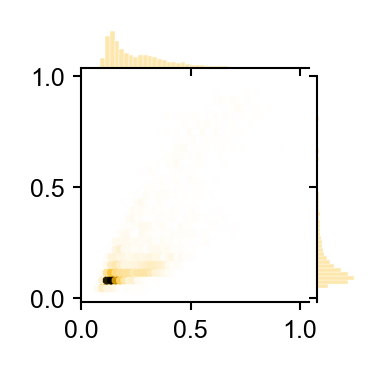

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
palette = ["#F2764D","#FDDF91"]
# 设定 EID
eid = 'E118'

# 读取数据
data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')
data = data[data['eid'] == eid]
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

# 设定随机种子
seed = 123
np.random.seed(seed)

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 加载并打乱数据

# 数据合并
data = pd.merge(data, meta[['gene_id', 'mean', 'mean_label', 'sc_exp_label', 'cv_label']], how='inner', on='gene_id')

g = sns.jointplot(
    data=data[data['sc_exp_label'] == 0],
    x='bs_label_score', 
    y='bf_label_score', 
    color=palette[1], kind="hex",
    height=3/2.54,     # 主图高度（单位：英寸）
    # ratio=3.5/2.54, 
)

g.ax_joint.set_ylabel('', fontsize=6)
g.ax_joint.set_xlabel('', fontsize=6)
g.ax_joint.set_title('', fontsize=6, fontweight='regular',y=1.1)

# g.ax_joint.set_xticks([0, 0.5, 1.0],labels=[])
# g.ax_joint.set_yticks([0, 0.5, 1.0],labels=[])
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])


import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[1], label='High expression'),
    mpatches.Patch(color=palette[0], label='Low expression'),
]
# fig.legend(handles=legend_patches, title=None, loc="upper left", bbox_to_anchor=(0.95, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

# **保存图像**
plt.savefig(f'extra/figures/v7/Figure2D_{eid}_2.eps', format='eps', bbox_inches='tight')

# 显示图像
plt.show()

# Figure 2F

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/3973716508.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], )
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/3973716508.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])


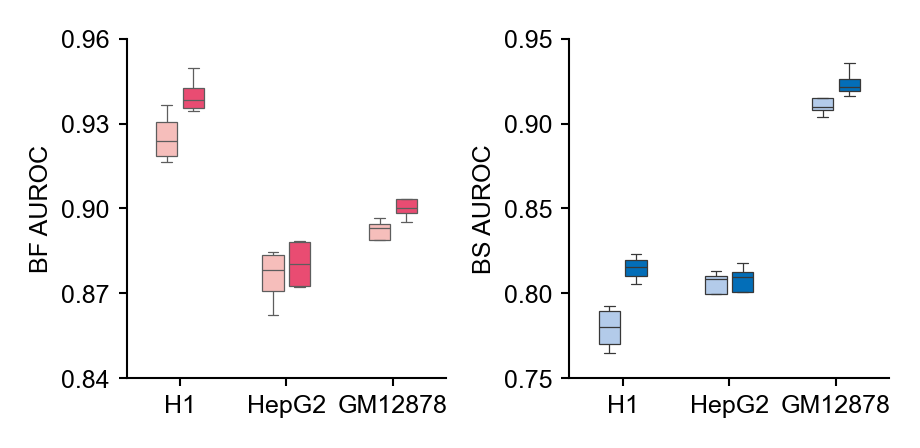

In [14]:
cell_type_agnostic = pd.read_csv(f'extra/results/cell_type_agnostic_bs_bf_para.csv',sep='\t')
cell_type_agnostic['cell_type'] = 'Agnostic_model'
cell_type_specific = pd.read_csv('extra/results/cell_type_specific_bs_bf_para.csv',sep='\t')
cell_type_specific['cell_type'] = 'Specific_model'
data = pd.concat([cell_type_specific,cell_type_agnostic], axis=0)
data['bf_auc'] = data['bf_auc'] / 100
data['bs_auc'] = data['bs_auc'] / 100


# 设置为 colorblind 调色板
fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7.5/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = ['Agnostic_model','Specific_model',]

palette = ['#F6BEBB',"#E94C72"]
sns.boxplot(data=data, x='eid',y='bf_auc',hue='cell_type',fliersize=0, linewidth=0.3,ax=ax[0],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)

palette = ['#B3CBEA',"#036EB8"]
sns.boxplot(data=data, x='eid',y='bs_auc',hue='cell_type',fliersize=0, linewidth=0.3,ax=ax[1],order=order,hue_order=hue_order,
            gap=0.2,width=0.5,palette=palette,saturation=1)


ax[0].set_xlabel('')
ax[0].set_ylabel(f'BF AUROC',fontsize=6)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], )
ax[0].set_ylim(0.84)
yticks = [i/100 for i in range(84,97,3)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[0].set_yticks(yticks, labels=yticklabels)


ax[1].set_ylabel(f'BS AUROC',fontsize=6)
ax[1].set_xlabel('')
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order])
ax[1].set_ylim(0.75)
yticks = [i/100 for i in range(75,96,5)]
yticklabels = [f"{i:.2f}" for i in yticks]
ax[1].set_yticks(yticks, labels=yticklabels)

handles, labels = ax[0].get_legend_handles_labels()
labels = [ "Cell-type specific model","Cell-type agnostic model"]

# Add a legend at the upper right of the 3rd subplot (1st row, 3rd column)
# fig.legend(handles, labels, loc='upper left',title=None ,title_fontsize=6, bbox_to_anchor=(0.98, 1.02), fontsize=5,ncol=1,edgecolor='none',handlelength=1.3 ,columnspacing=1.5)
plt.savefig('extra/figures/v7/Figure2F.eps', format='eps', bbox_inches='tight')

# Show the plot
plt.show()

# Figure 2G

      bs_auc    bf_auc  fold train_eid valid_eid
0   0.916103  0.899636     0      E116      E116
1   0.923317  0.911211     1      E116      E116
2   0.935525  0.895294     2      E116      E116
3   0.920027  0.900732     3      E116      E116
4   0.769961  0.836924     0      E116      E118
5   0.794891  0.871671     1      E116      E118
6   0.797551  0.859138     2      E116      E118
7   0.808932  0.846971     3      E116      E118
8   0.768496  0.912833     0      E116      E003
9   0.792555  0.920894     1      E116      E003
10  0.791625  0.906458     2      E116      E003
11  0.774889  0.902224     3      E116      E003
12  0.909276  0.881760     0      E118      E116
13  0.916337  0.876816     1      E118      E116
14  0.923011  0.847687     2      E118      E116
15  0.908565  0.874051     3      E118      E116
16  0.776444  0.872285     0      E118      E118
17  0.809220  0.888016     1      E118      E118
18  0.810618  0.888596     2      E118      E118
19  0.818125  0.8728

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/3475614119.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/3475614119.py:11: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_68842/3475614119.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_yticklabels([f"" for eid in order])
/var/folders/tg/cls39crs7

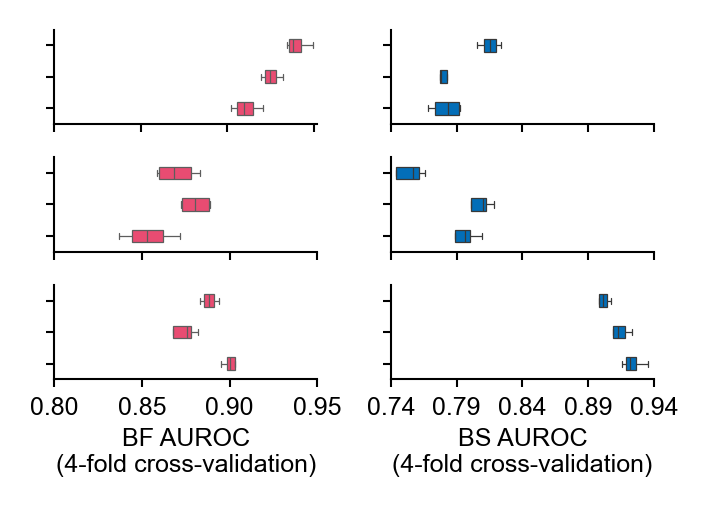

In [16]:
data = pd.read_csv("extra/results/cross_cell_type_bs_bf_para.csv",sep='\t')
data['bf_auc'] = data['bf_auc'] / 100
data['bs_auc'] = data['bs_auc'] / 100

print(data)
order = pd.Index(["E003","E118","E116"],name='marks')
valid_eid = 'E003'

fig, ax = plt.subplots(3, 2, constrained_layout=True, figsize=(5.7/2.54, 4/2.54))
palette = ["#E94C72"]
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[0,0],saturation=1)

ax[0,0].set_ylabel("",fontsize=6)
ax[0,0].set_yticklabels([f"" for eid in order])
ax[0,0].set_xlabel("",fontsize=6)
ax[0,0].set_xlim(0.80)
xticks = [i/100 for i in range(80,97,5)]
ax[0,0].set_xticks(xticks, labels=[f"" for i in xticks])

# ax[0,0].set_xticklabels("",fontsize=6)
palette = ['#036EB8']
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bs_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[0,1],saturation=1)

ax[0,1].set_ylabel("",fontsize=6)
ax[0,1].set_yticklabels([f"" for eid in order])
ax[0,1].set_xlabel("",fontsize=6)

ax[0,1].set_xlim(0.74)
xticks = [i/100 for i in range(74,95,5)]
ax[0,1].set_xticks(xticks, labels=[f"" for i in xticks])


valid_eid = 'E118'
palette = ["#E94C72"]
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[1,0],saturation=1)

ax[1,0].set_ylabel("",fontsize=6)
# ax[1,0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]} → {EIDS_TO_CELLTYPES[valid_eid]}" for eid in order])
ax[1,0].set_yticklabels([f"" for eid in order])
ax[1,0].set_xlabel("",fontsize=6)
ax[1,0].set_xlim(0.80)
xticks = [i/100 for i in range(80,97,5)]
# xticklabels = [f"{i:.2f}" for i in xticks]
ax[1,0].set_xticks(xticks, labels=[f"" for i in xticks])
# ax[0].set_title('Burst frequency',fontsize=6)
palette = ['#036EB8']
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bs_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[1,1],saturation=1)

ax[1,1].set_ylabel("",fontsize=6)
ax[1,1].set_yticklabels([f"" for eid in order])
ax[1,1].set_xlabel("",fontsize=6)
ax[1,1].set_xlim(0.74)
xticks = [i/100 for i in range(74,95,5)]
ax[1,1].set_xticks(xticks, labels=[f"" for i in xticks])

valid_eid = 'E116'
palette = ["#E94C72"]
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[2,0],saturation=1)

ax[2,0].set_ylabel("",fontsize=6)
# ax[2,0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]} → {EIDS_TO_CELLTYPES[valid_eid]}" for eid in order])
ax[2,0].set_yticklabels([f"" for eid in order])
ax[2,0].set_xlabel("BF AUROC\n(4-fold cross-validation)",fontsize=6)
ax[2,0].set_xlim(0.80)
xticks = [i/100 for i in range(80,97,5)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[2,0].set_xticks(xticks, labels=xticklabels)
# ax[0].set_title('Burst frequency',fontsize=6)
palette = ['#036EB8']
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bs_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[2,1],saturation=1)

ax[2,1].set_ylabel("",fontsize=6)
ax[2,1].set_yticklabels([f"" for eid in order])
ax[2,1].set_xlim(0.74)
xticks = [i/100 for i in range(74,95,5)]
xticklabels = [f"{i:.2f}" for i in xticks]
ax[2,1].set_xticks(xticks, labels=xticklabels)

ax[2,1].set_xlabel("BS AUROC\n(4-fold cross-validation)",fontsize=6)

plt.savefig('extra/figures/v7/Figure2G.eps', format='eps', bbox_inches='tight')


plt.show()

# Supplementary

       bs_auc     bf_auc  fold train_eid valid_eid
0   78.889576  95.577691     0      E116      E116
1   78.517707  95.789019     1      E116      E116
2   80.113827  96.021380     2      E116      E116
3   78.527993  96.246532     3      E116      E116
4   65.420962  91.197954     0      E116      E118
5   67.872840  92.172294     1      E116      E118
6   66.913754  91.820423     2      E116      E118
7   66.915031  93.118094     3      E116      E118
8   69.974319  90.635944     0      E116      E003
9   67.727646  92.558474     1      E116      E003
10  70.154359  92.800986     2      E116      E003
11  70.631949  92.737666     3      E116      E003
12  77.029918  94.808794     0      E118      E116
13  75.934736  93.886406     1      E118      E116
14  79.088733  94.530433     2      E118      E116
15  77.269171  95.154135     3      E118      E116
16  67.000803  93.336795     0      E118      E118
17  69.899032  93.624790     1      E118      E118
18  69.135913  93.860566     2 

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_14769/3388374021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_14769/3388374021.py:8: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_14769/3388374021.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]} -> {EIDS_TO_CELLTYPES[val

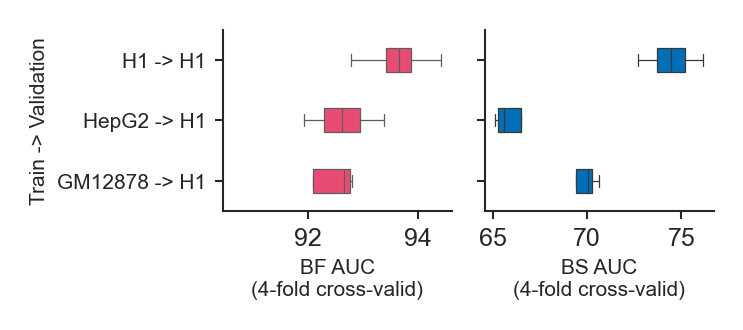

In [ ]:
data = pd.read_csv("extra/results/cross_cell_type_bs_bf_para.csv",sep='\t')
print(data)
order = pd.Index(["E003","E118","E116"],name='marks')
valid_eid = 'E003'

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(6/2.54, 2.5/2.54))
palette = ["#E94C72"]
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bf_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[0],saturation=1)

ax[0].set_ylabel("",fontsize=6)
ax[0].tick_params(axis='x', labelsize=6,width=0.5)
ax[0].tick_params(axis='y', labelsize=5,width=0.5)
ax[0].set_yticklabels([f"{EIDS_TO_CELLTYPES[eid]} -> {EIDS_TO_CELLTYPES[valid_eid]}" for eid in order])
ax[0].set_xlabel("BF AUC\n(4-fold cross-validation)",fontsize=5)
ax[0].set_ylabel("Train -> Validation",fontsize=5)
# ax[0].set_title('Burst frequency',fontsize=6)
palette = ['#036EB8']
sns.boxplot(data=data[data['valid_eid']==valid_eid],y='train_eid',x='bs_auc',fliersize=0, linewidth=0.3,order=order,
            gap=0.2,width=0.5,palette=palette,ax=ax[1],saturation=1)

ax[1].set_ylabel("",fontsize=6)
ax[1].tick_params(axis='x', labelsize=6,width=0.5)
ax[1].tick_params(axis='y', labelsize=5,width=0.5)
ax[1].set_yticklabels([f"" for eid in order])
ax[1].set_xlabel("BS AUC\n(4-fold cross-validation)",fontsize=5)

plt.savefig('extra/figures/v6/Supplementary_Figure2D_1.eps', format='eps', bbox_inches='tight')


plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


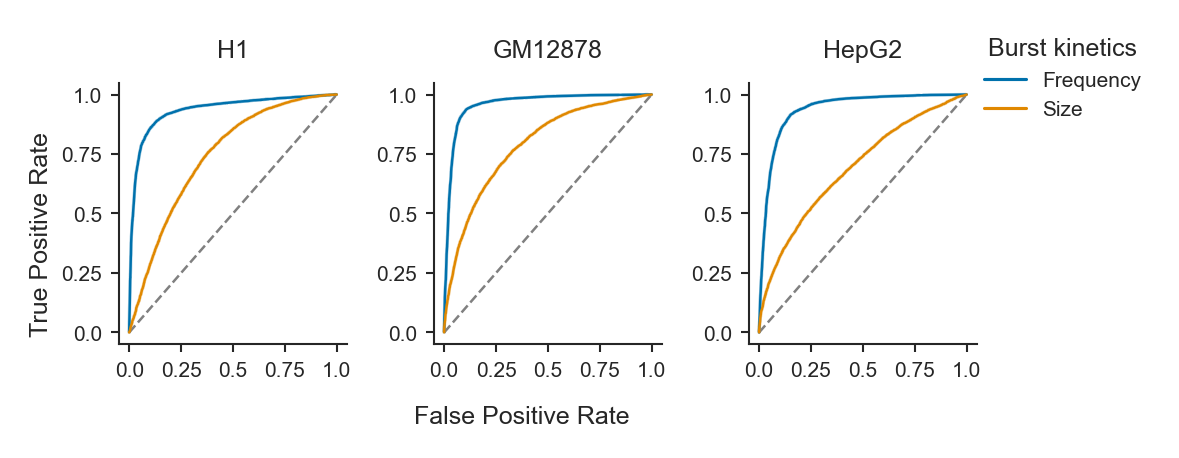

In [ ]:
# 

fig, ax = plt.subplots(1, 3, constrained_layout=True, figsize=(8/2.54, 3.5/2.54))

eid = 'E003'
data = pd.read_csv('extra/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

sns.lineplot(x=fpr,y=tpr,ax=ax[0],linewidth=0.6,color="#0071AC")
sns.lineplot(x=[0, 1], y=[0, 1], ax=ax[0], color='gray', linestyle='--', linewidth=0.6)

fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
sns.lineplot(x=fpr,y=tpr,ax=ax[0],linewidth=0.6,color="#E08800")

ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title(f"{EIDS_TO_CELLTYPES[eid]}",fontsize=6,fontweight='regular')
ax[0].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[0].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])

eid = 'E116'
data = pd.read_csv('extra/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

sns.lineplot(x=fpr,y=tpr,ax=ax[1],linewidth=0.6,color="#0071AC")
sns.lineplot(x=[0, 1], y=[0, 1], ax=ax[1], color='gray', linestyle='--', linewidth=0.6)


fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
sns.lineplot(x=fpr,y=tpr,ax=ax[1],linewidth=0.6,color="#E08800")
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_title(f"{EIDS_TO_CELLTYPES[eid]}",fontsize=6,fontweight='regular')
ax[1].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[1].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])

eid = 'E118'
data = pd.read_csv('extra/results/predictions_bs_bf.csv')
data = data[data['eid']==eid]
fpr, tpr, _ = metrics.roc_curve(data['bf_label_label'], data['bf_label_score'])
roc_auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(data['bf_label_label'],data['bf_label_pred'])

sns.lineplot(x=fpr,y=tpr,ax=ax[2],linewidth=0.6,color="#0071AC")
sns.lineplot(x=[0, 1], y=[0, 1], ax=ax[2], color='gray', linestyle='--', linewidth=0.6)

fpr, tpr, _ = metrics.roc_curve(data['bs_label_label'], data['bs_label_score'])
roc_auc = metrics.auc(fpr, tpr)
sns.lineplot(x=fpr,y=tpr,ax=ax[2],linewidth=0.6,color="#E08800")


fig.supxlabel('False Positive Rate',fontsize=6,)
fig.supylabel('True Positive Rate',fontsize=6,x=-0.02)
ax[2].set_xlabel('')
ax[2].set_ylabel('')
ax[2].set_title(f"{EIDS_TO_CELLTYPES[eid]}",fontsize=6,fontweight='regular')
ax[2].set_xticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
ax[2].set_yticks([i/100 for i in range(0, 101, 25)],labels=[i/100 for i in range(0, 101, 25)])
# Add a colorbar
import matplotlib.lines as mlines
legend_lines = [
    mlines.Line2D([], [], color="#0071AC", linestyle="-", label='Frequency'),
    mlines.Line2D([], [], color="#E08800", linestyle="-", label='Size'),
]

fig.legend(handles=legend_lines, title="Burst kinetics",loc="upper left", bbox_to_anchor=(0.97, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

plt.savefig('extra/figures/v5/Supplementary_figure2E.eps', format='eps', bbox_inches='tight')

plt.show()

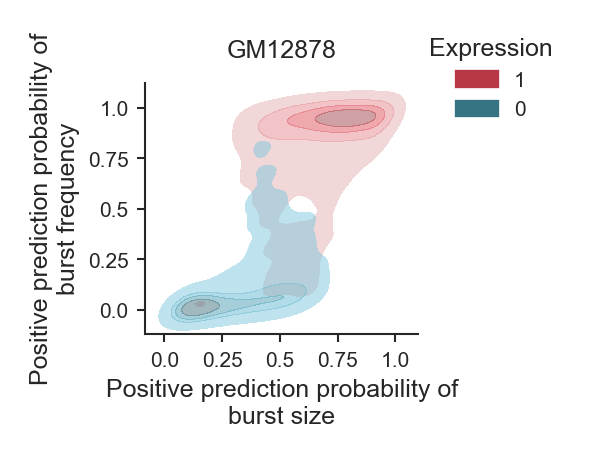

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
palette = ["#377483","#B83945"]
# 设定 EID
eid = 'E116'

# 读取数据
data = pd.read_csv(f'extra/results/{eid}_predictions_bs_bf.csv')
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_1.0_with_cellsize_1.csv"

# 设定随机种子
seed = 123
np.random.seed(seed)

meta = (
    pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
)  # 加载并打乱数据

# 数据合并
data = pd.merge(data, meta[['gene_id', 'mean', 'mean_label', 'sc_exp_label', 'cv_label']], how='inner', on='gene_id')

# 创建画布
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(3.5/2.54, 3.5/2.54))

# **第一个子图 - Mean Label**

sns.kdeplot(
    data=data[data['sc_exp_label'] == 1],
    x='bs_label_score', 
    y='bf_label_score', 
    ax=ax, color=palette[1], fill=True, levels=5, alpha=0.5
)

sns.kdeplot(
    data=data[data['sc_exp_label'] == 0],
    x='bs_label_score', 
    y='bf_label_score', 
    ax=ax, color=palette[0], fill=True, levels=5, alpha=0.5
)



ax.set_ylabel('Positive prediction probability of\nburst frequency', fontsize=6)
ax.set_xlabel('Positive prediction probability of\nburst size', fontsize=6)
ax.set_xticks([i / 100 for i in range(0, 101, 25)], labels=[i / 100 for i in range(0, 101, 25)])
ax.set_yticks([i / 100 for i in range(0, 101, 25)], labels=[i / 100 for i in range(0, 101, 25)])
ax.set_title(f'{EIDS_TO_CELLTYPES[eid]}', fontsize=6, fontweight='regular')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[1], label=1),
    mpatches.Patch(color=palette[0], label=0),
]
fig.legend(handles=legend_patches, title="Expression", loc="upper left", bbox_to_anchor=(0.95, 1.02), title_fontsize=6,fontsize=5, ncol=1,edgecolor='none')

# **保存图像**
plt.savefig('extra/figures/v5/Supplementary_figure2E_3.svg', format='svg', bbox_inches='tight')

# 显示图像
plt.show()

# label stability

    eid        bf        bs
0  E003  0.918623  0.821109
0  E118  0.853875  0.811661
0  E116  0.815431  0.692796


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_88428/2111040664.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)


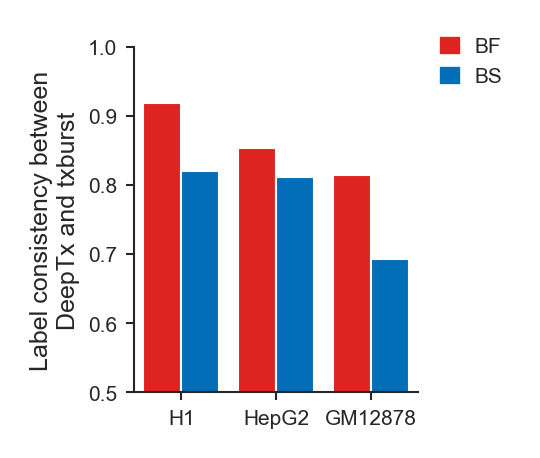

In [ ]:

eid = 'E116'

def compute_label_statistics(eid,threshold=0):

    labels_deeptx = pd.read_csv(f'extra/datasets/burst/labels/deeptx/{EIDS_TO_CELLTYPES[eid]}_estimated_burst.csv')
    labels_deeptx = labels_deeptx.fillna(0.0)
    bs_median = np.median(labels_deeptx['bs'])
    bf_median = np.median(labels_deeptx['bf'])

    labels_deeptx['bs_label'] = labels_deeptx.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
    labels_deeptx['bf_label'] = labels_deeptx.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)

    labels_txburst = pd.read_csv(f'extra/datasets/burst/processed/{EIDS_TO_CELLTYPES[eid]}_statistic_gene_transcript_region_delay_1.csv')
    bs_median = np.median(labels_txburst['bs'])
    bf_median = np.median(labels_txburst['bf'])
    labels_txburst['mean'] = labels_txburst['bf']*labels_txburst['bs']

    labels_txburst['bs_label'] = labels_txburst.apply(lambda row: 1 if row['bs'] > bs_median else 0, axis=1)
    labels_txburst['bf_label'] = labels_txburst.apply(lambda row: 1 if row['bf'] > bf_median else 0, axis=1)

    data = pd.merge(labels_deeptx[['gene_name','bf','bs',f'bf_label','bs_label','mean_true']],labels_txburst[['gene_name','bf','bs','bf_label','bs_label','mean']],on='gene_name',suffixes=['_deeptx','_txburst'])
    data_exp = data[data['mean'] > threshold]
    data_no_exp = data[data['mean'] <= threshold]
    # data.to_csv('tests/test.csv',index=False)
    consistency = {
        'eid':eid,
        'bf':[(data_exp[data_exp[f'bf_label_deeptx']==data_exp[f'bf_label_txburst']].shape[0] + data_no_exp.shape[0])/data.shape[0]],
        'bs':[(data_exp[data_exp[f'bs_label_deeptx']==data_exp[f'bs_label_txburst']].shape[0] + data_no_exp.shape[0])/data.shape[0]]
        }

    return consistency

eid = 'E003'
threshold = 0
consistency_E003 = compute_label_statistics(eid,threshold)
consistency_E003 = pd.DataFrame(consistency_E003)

eid = 'E118'
consistency_E116 = compute_label_statistics(eid,threshold)
consistency_E116 = pd.DataFrame(consistency_E116)

eid = 'E116'
consistency_E118 = compute_label_statistics(eid,threshold)
consistency_E118 = pd.DataFrame(consistency_E118)


consistency_df = pd.concat([consistency_E003, consistency_E116, consistency_E118], axis=0)
print(consistency_df)

consistency_df = pd.melt(
    consistency_df,
    id_vars='eid',             # 不展开 eid 列
    value_vars=['bf', 'bs'],   # 要展开的列
    var_name='burst_type',     # 新列名：表示是 bf 还是 bs
    value_name='consistency'   # 新列名：对应的值
)


order = pd.Index(["E003","E118","E116"],name='marks')
data = pd.read_csv(f'extra/results/predictions_bs_bf.csv')

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(3.5/2.54, 3.5/2.54))
palette1 = ["#DD2421","#036EB8"]
sns.barplot(
    data=consistency_df,
    x='eid',
    y='consistency',
    hue='burst_type',
    palette=palette1,
    linewidth=0.5,
    saturation=1,
    order=order,
)

ax.set_ylabel('Label consistency between\nDeepTx and txburst', fontsize=6)
ax.set_xlabel('',fontsize=6)
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)
ax.set_ylim(0.5,1.0)
ax.legend().remove()

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette1[0], label='BF'),
    mpatches.Patch(color=palette1[1], label='BS'),
]
fig.legend(
    handles=legend_patches, 
    title="", 
    handlelength=2/2.54,      # 控制色块的水平长度
    handleheight=1.7/2.54,      # 控制色块的垂直高度（仅在 fancybox=True 时有明显效果）
    loc="upper left", 
    bbox_to_anchor=(0.98, 1.02), 
    title_fontsize=6,
    fontsize=5, 
    ncol=1,
    edgecolor='none')

plt.show()


In [18]:
def compute_sampling_probabillity_consistency(data1, data2,threshold=0.0):


    data = pd.merge(data1, data2, on='gene_id', suffixes=('_delay1', '_delay2'))
    data_exp = data[data['mean_delay2'] >= threshold]
    data_no_exp = data[data['mean_delay2'] < threshold]

    consistency = {
        'eid':eid,
        'bf':[(data_exp[data_exp[f'bf_label_delay1']==data_exp[f'bf_label_delay2']].shape[0] + data_no_exp.shape[0])/data.shape[0]],
        'bs':[(data_exp[data_exp[f'bs_label_delay1']==data_exp[f'bs_label_delay2']].shape[0] + data_no_exp.shape[0])/data.shape[0]]
        }

    return consistency

## txburst

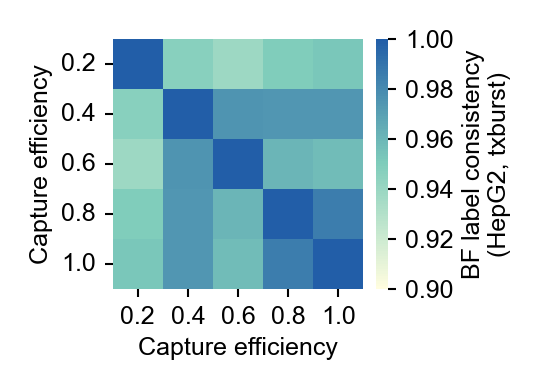

In [46]:
delays = [0.2,0.4,0.6,0.8,1.0]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.3/2.54, 4.3/2.54))

eid = 'E118'
consistency_matrix = np.zeros((len(delays), len(delays), 2))  # 2 for bf and bs
for idx1, delay1 in enumerate(delays):
    for idx2, delay2 in enumerate(delays):
        data1 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}_delay_{delay1}.csv')
        data1 = data1[['gene_id', 'bs_label', 'bf_label','mean']]
        data2 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}_delay_{delay2}.csv')
        data2 = data2[['gene_id', 'bs_label', 'bf_label','mean']]
        consistency = compute_sampling_probabillity_consistency(data1, data2)
        consistency_matrix[idx1, idx2, 0] = consistency['bf'][0]
        consistency_matrix[idx1, idx2, 1] = consistency['bs'][0]


COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
ax = sns.heatmap(consistency_matrix[:,:,0],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0.9, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))

ticks =  [str(float(delay)) for delay in delays]
ax.set_xticklabels(ticks,rotation=0)
ax.set_yticklabels(ticks,rotation=0)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
ax.set_xlabel('Capture efficiency', fontsize=6)
ax.set_ylabel('Capture efficiency', fontsize=6)
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=6)  # 设置colorbar刻度的粗细
cbar.set_label(f'BF label consistency\n({EIDS_TO_CELLTYPES[eid]}, txburst)',fontsize=6)

# plt.savefig('extra/figures/v6/Supplementary_Figure2B_3.eps', format='eps', bbox_inches='tight')



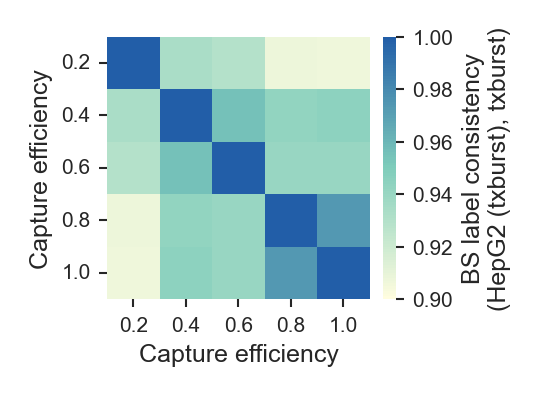

In [ ]:
delays = [0.2,0.4,0.6,0.8,1]

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(4.3/2.54, 4.3/2.54))

eid = 'E116'
consistency_matrix = np.zeros((len(delays), len(delays), 2))  # 2 for bf and bs
for idx1, delay1 in enumerate(delays):
    for idx2, delay2 in enumerate(delays):
        data1 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}_delay_{delay1}.csv')
        data1 = data1[['gene_id', 'bs_label', 'bf_label','mean']]
        data2 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}_delay_{delay2}.csv')
        data2 = data2[['gene_id', 'bs_label', 'bf_label','mean']]
        consistency = compute_sampling_probabillity_consistency(data1, data2)
        consistency_matrix[idx1, idx2, 0] = consistency['bf'][0]
        consistency_matrix[idx1, idx2, 1] = consistency['bs'][0]


COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
ax = sns.heatmap(consistency_matrix[:,:,1],cbar_kws={"shrink": 0.6, "fraction": 0.05},vmin=0.9, vmax=1,cmap=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100))

ticks =  [str(float(delay)) for delay in delays]
ax.set_xticklabels(ticks,rotation=0)
ax.set_yticklabels(ticks,rotation=0)
ax.set_aspect('equal')
ax.tick_params(axis='both',width=0.5)  # 修改刻度标签字体大小
ax.set_xlabel('Capture efficiency', fontsize=6)
ax.set_ylabel('Capture efficiency', fontsize=6)
cbar = ax.collections[0].colorbar

# 调整colorbar的刻度粗细
cbar.ax.tick_params(width=0.5,labelsize=5)  # 设置colorbar刻度的粗细
cbar.set_label(f'BS label consistency\n({EIDS_TO_CELLTYPES[eid]}, txburst)',fontsize=6)
plt.savefig('extra/figures/v6/Supplementary_Figure2B_5.eps', format='eps', bbox_inches='tight')


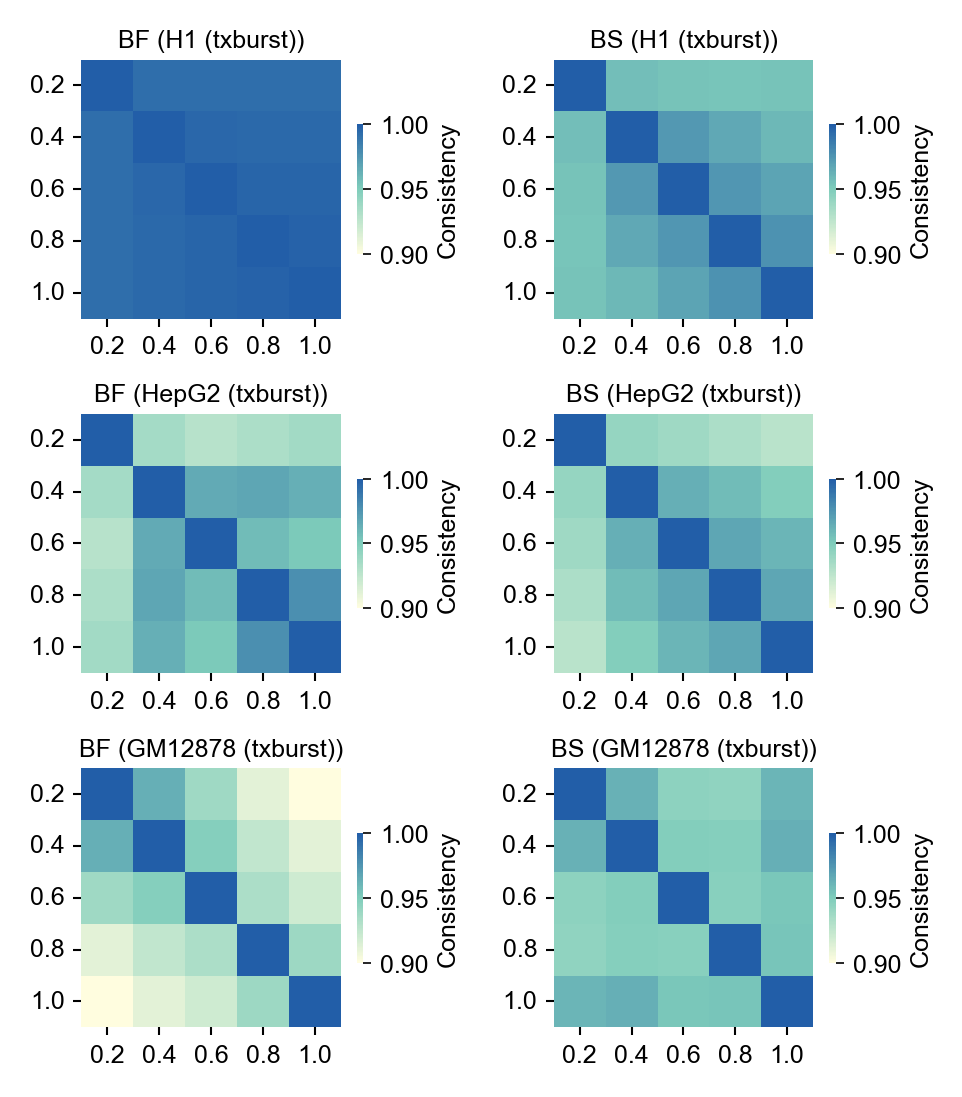

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors



EIDS_TO_CELLTYPES = {
    'E003': 'H1 (txburst)',
    'E118': 'HepG2 (txburst)',
    'E116': 'GM12878 (txburst)'
}

delays = [0.2, 0.4, 0.6, 0.8, 1.0]
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
cmap = mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100)

# --------------------------------------------
# 计算一致性矩阵函数
# --------------------------------------------
def compute_consistency_matrix(eid):
    matrix = np.zeros((len(delays), len(delays), 2))
    for i, d1 in enumerate(delays):
        for j, d2 in enumerate(delays):
            data1 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_{d1}_with_cellsize_1.csv')
            data2 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_delay_{d2}_with_cellsize_1.csv')
            consistency = compute_sampling_probabillity_consistency(data1, data2)
            matrix[i, j, 0] = consistency['bf'][0]
            matrix[i, j, 1] = consistency['bs'][0]
    return matrix

# --------------------------------------------
# 绘制 3×2 热图
# --------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(8/2.54, 9/2.54), constrained_layout=True)

for row, eid in enumerate(['E003', 'E118', 'E116']):  # H1, HepG2, GM12878
    consistency_matrix = compute_consistency_matrix(eid)
    cell_label = EIDS_TO_CELLTYPES[eid]

    for col, metric in enumerate(['bf', 'bs']):
        ax = axes[row, col]
        data = consistency_matrix[:, :, 0] if metric == 'bf' else consistency_matrix[:, :, 1]

        sns.heatmap(
            data, ax=ax, cmap=cmap,
            vmin=0.9, vmax=1.0,
            cbar_kws={"shrink": 0.5, "fraction": 0.05},
        )
        
        # 设置刻度
        ticks =  [str(float(delay)) for delay in delays]
        ax.set_xticklabels(ticks, rotation=0)
        ax.set_yticklabels(ticks, rotation=0)
        ax.set_aspect('equal')

        # 坐标轴标题
        if row == 2:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('')

        # 设置标题
        title = 'BF' if metric == 'bf' else 'BS'
        ax.set_title(f"{title} ({cell_label})", pad=3)

        # Colorbar 调整
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(width=0.4, )
        cbar.set_label("Consistency", )

# --------------------------------------------
# 保存图像
# --------------------------------------------
plt.savefig('extra/figures/v7/Supplementary_Figure3C.eps', format='eps', bbox_inches='tight')
plt.show()

## deeptx

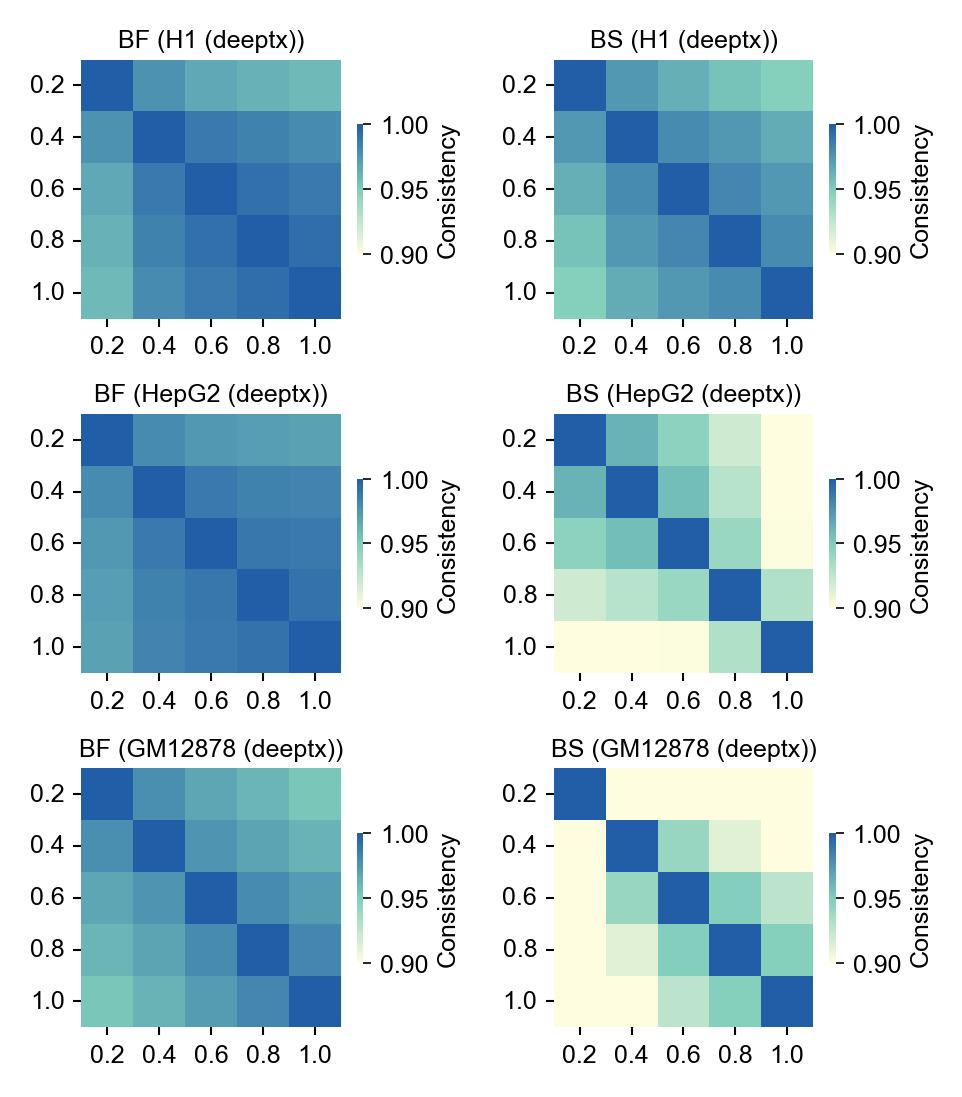

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors



EIDS_TO_CELLTYPES = {
    'E003': 'H1 (deeptx)',
    'E118': 'HepG2 (deeptx)',
    'E116': 'GM12878 (deeptx)'
}

delays = [0.2, 0.4, 0.6, 0.8, 1.0]
COLORS = ['#FFFDDF', "#7FCDBB", "#225EA8"]
cmap = mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=100)

# --------------------------------------------
# 计算一致性矩阵函数
# --------------------------------------------
def compute_consistency_matrix(eid):
    matrix = np.zeros((len(delays), len(delays), 2))
    for i, d1 in enumerate(delays):
        for j, d2 in enumerate(delays):
            data1 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_deeptx_delay_{d1}.csv')
            data2 = pd.read_csv(f'extra/datasets/processed/v2/meta_datasets/meta_data_{eid}_deeptx_delay_{d2}.csv')
            consistency = compute_sampling_probabillity_consistency(data1, data2)
            matrix[i, j, 0] = consistency['bf'][0]
            matrix[i, j, 1] = consistency['bs'][0]
    return matrix

# --------------------------------------------
# 绘制 3×2 热图
# --------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(8/2.54, 9/2.54), constrained_layout=True)

for row, eid in enumerate(['E003', 'E118', 'E116']):  # H1, HepG2, GM12878
    consistency_matrix = compute_consistency_matrix(eid)
    cell_label = EIDS_TO_CELLTYPES[eid]

    for col, metric in enumerate(['bf', 'bs']):
        ax = axes[row, col]
        data = consistency_matrix[:, :, 0] if metric == 'bf' else consistency_matrix[:, :, 1]

        sns.heatmap(
            data, ax=ax, cmap=cmap,
            vmin=0.9, vmax=1.0,
            cbar_kws={"shrink": 0.5, "fraction": 0.05},
        )
        
        # 设置刻度
        ticks =  [str(float(delay)) for delay in delays]
        ax.set_xticklabels(ticks, rotation=0)
        ax.set_yticklabels(ticks, rotation=0)
        ax.set_aspect('equal')

        # 坐标轴标题
        if row == 2:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('')

        # 设置标题
        title = 'BF' if metric == 'bf' else 'BS'
        ax.set_title(f"{title} ({cell_label})", pad=3)

        # Colorbar 调整
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(width=0.4, )
        cbar.set_label("Consistency", )

# --------------------------------------------
# 保存图像
# --------------------------------------------
plt.savefig('extra/figures/v7/Supplementary_Figure3D.eps', format='eps', bbox_inches='tight')
plt.show()

In [21]:
eid = 'E003'
meta_data = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}_delay_1.csv')
meta_data['bf_1'] = meta_data.apply(lambda row: 0 if row['expression'] < 0.5 else row['bf'], axis=1)
meta_data['bs_1'] = meta_data.apply(lambda row: 0 if row['expression'] < 0.5 else row['bs'], axis=1)
bs_median = np.median(meta_data['bs'])
bf_median = np.median(meta_data['bf'])
bs_1_median = 0.1 if np.median(meta_data['bs_1']) < 0.1 else np.median(meta_data['bs_1'])
bf_1_median = 0.1 if np.median(meta_data['bf_1']) < 0.1 else np.median(meta_data['bf_1'])


print(bs_median,bf_median,bs_1_median,bf_1_median)

meta_data['bs_1_label'] = meta_data.apply(lambda row: 1 if row['bs_1'] > bs_1_median else 0, axis=1)
meta_data['bf_1_label'] = meta_data.apply(lambda row: 1 if row['bf_1'] > bf_1_median else 0, axis=1)
meta_data[~(meta_data['bs_label']==meta_data['bs_1_label'])][meta_data['expression'] < 0.5][['expression','bs','bf','bs_1','bf_1','bs_label','bf_label','bs_1_label','bf_1_label']]
# sns.histplot(np.log1p(meta_data['bs_1']))


30.197436397902443 0.041927718048354656 17.909212380713647 0.1


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_88428/4161761610.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  meta_data[~(meta_data['bs_label']==meta_data['bs_1_label'])][meta_data['expression'] < 0.5][['expression','bs','bf','bs_1','bf_1','bs_label','bf_label','bs_1_label','bf_1_label']]


,expression,bs,bf,bs_1,bf_1,bs_label,bf_label,bs_1_label,bf_1_label
3,0.100890,64.678301,0.002220,0.0,0.0,1,0,0,0
25,0.124629,52.334413,0.003097,0.0,0.0,1,0,0,0
45,0.359050,52.710411,0.007340,0.0,0.0,1,0,0,0
52,0.198813,67.275235,0.003767,0.0,0.0,1,0,0,0
53,0.145401,32.217911,0.006188,0.0,0.0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
14371,0.370920,48.050787,0.008875,0.0,0.0,1,0,0,0
14386,0.005935,64.237688,0.001000,0.0,0.0,1,0,0,0
14395,0.094955,31.569015,0.004406,0.0,0.0,1,0,0,0
14411,0.023739,76.342376,0.001000,0.0,0.0,1,0,0,0


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_11551/3707218822.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)


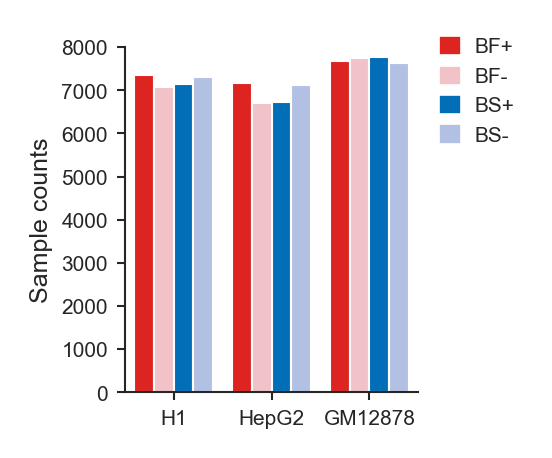

In [13]:
eid = 'E003'
meta_data_E003 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv')
meta_data_E003 = meta_data_E003[['bs_label','bf_label']]
meta_data_E003['eid'] = eid

eid = 'E118'
meta_data_E118 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv')
meta_data_E118 = meta_data_E118[['bs_label','bf_label']]
meta_data_E118['eid'] = eid

eid = 'E116'
meta_data_E116 = pd.read_csv(f'extra/datasets/processed/v1/meta_datasets/meta_data_{eid}.csv')
meta_data_E116 = meta_data_E116[['bs_label','bf_label']]
meta_data_E116['eid'] = eid

meta_data = pd.concat([meta_data_E003, meta_data_E118, meta_data_E116], axis=0)

samples_counts_bs_label = meta_data.groupby(['eid', 'bs_label']).size().reset_index(name='counts')
samples_counts_bs_label.columns = ['eid', 'label', 'counts']
samples_counts_bs_label['target'] = 'bs'
samples_counts_bf_label = meta_data.groupby(['eid', 'bf_label']).size().reset_index(name='counts')
samples_counts_bf_label.columns = ['eid', 'label', 'counts']
samples_counts_bf_label['target'] = 'bf'
samples_counts = pd.concat([samples_counts_bs_label, samples_counts_bf_label], axis=0)
samples_counts['label'] = samples_counts['target'].astype(str)+'_'+ samples_counts['label'].astype(str)
samples_counts

fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(3.5/2.54, 3.5/2.54))
hue_order = ['bf_1', 'bf_0', 'bs_1', 'bs_0']

palette = ["#DD2421","#F1C3C8","#036EB8","#B2C1E3"] 

order = pd.Index(["E003","E118","E116"],name='marks')
sns.barplot(samples_counts, x='eid', y='counts', hue='label',order=order, hue_order=hue_order, palette=palette, linewidth=0.5, saturation=1)

ax.set_ylabel('Sample counts', fontsize=6)
ax.set_xlabel('', fontsize=6)
ax.set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,fontsize=5)
ax.set_ylim(0, 8000)
ax.legend().remove()

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=palette[0], label='BF+'),
    mpatches.Patch(color=palette[1], label='BF-'),
    mpatches.Patch(color=palette[2], label='BS+'),
    mpatches.Patch(color=palette[3], label='BS-'),

]

fig.legend(
    handles=legend_patches, 
    title="", 
    handlelength=2/2.54,      # 控制色块的水平长度
    handleheight=1.7/2.54,      # 控制色块的垂直高度（仅在 fancybox=True 时有明显效果）
    loc="upper left", 
    bbox_to_anchor=(0.98, 1.02), 
    title_fontsize=6,
    fontsize=5, 
    ncol=1,
    edgecolor='none'
)


